# 模块 1 节点壳（`/cluster`）调用示例

对应 `catkin_ws/src/uav_tracking/scripts/cluster_node.py`，演示节点壳**消息搬运**的两步转换与效果：

1. `cloud_to_points(msg)` —— `sensor_msgs/PointCloud2` → `list[Point3D]`；
2. `clusters_to_centroid_array(clusters, header)` —— `list[Cluster]` → `CentroidArray`。

中间夹着纯逻辑 `filter_ground` / `dbscan_cluster`（来自 `lib/cluster.py`，零改动）。

> **运行前提**：Jupyter 内核为系统 `python3`，且已 `source /opt/ros/noetic/setup.bash`、
> `source catkin_ws/devel/setup.bash`，并已 `catkin_make`。
> 本 notebook 不启动节点、不需 roscore——只演示可复用的转换函数。

In [1]:
import os
import sys

# 从当前目录向上查找仓库根（含 catkin_ws），使 notebook 在任意 cwd 下都能 import 节点壳
_here = os.path.abspath('.')
_repo = _here
while _repo != os.path.dirname(_repo) and not os.path.isdir(os.path.join(_repo, 'catkin_ws')):
    _repo = os.path.dirname(_repo)
SCRIPTS = os.path.join(_repo, 'catkin_ws', 'src', 'uav_tracking', 'scripts')
if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)

try:
    import cluster_node as cn
except Exception as exc:  # noqa: BLE001
    raise SystemExit(
        'import cluster_node 失败，请确认已 source ROS 与工作区并 catkin_make：\n'
        '  source /opt/ros/noetic/setup.bash\n'
        '  source catkin_ws/devel/setup.bash\n'
        '原始错误：%r' % (exc,))

import cluster as cl  # lib/cluster.py（cluster_node 已把它所在目录加入 sys.path）
print('repo root    :', _repo)
print('cluster_node :', cn.__file__)
print('STAGE =', cl.STAGE, '| ONBOARD =', cl.ONBOARD)


AttributeError: 'tuple' object has no attribute 'tb_frame'

## 0. 辅助

- `make_cloud(rows)`：用 `(x, y, z, intensity)` 行构造一帧 `PointCloud2`（等价于雷达插件发到 `/radar/points` 的消息）；
- `scene()`：合成一帧典型点云（两批地面杂波 + 两个空中目标簇）。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sensor_msgs.point_cloud2 as pc2
from sensor_msgs.msg import PointField
from std_msgs.msg import Header

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

C_RAW = '#9e9e9e'     # 原始点云
C_GROUND = '#c62828'  # 地面杂波（滤除）
C_AIR = '#1565c0'     # 空中点（保留）
C_CENT = '#2e7d32'    # 质心


def make_cloud(rows, with_intensity=True, frame_id='map'):
    fields = [PointField('x', 0, PointField.FLOAT32, 1),
              PointField('y', 4, PointField.FLOAT32, 1),
              PointField('z', 8, PointField.FLOAT32, 1)]
    if with_intensity:
        fields.append(PointField('intensity', 12, PointField.FLOAT32, 1))
    header = Header()
    header.frame_id = frame_id
    return pc2.create_cloud(header, fields, rows)


def scene():
    rng = np.random.default_rng(0)
    n = 400
    ground = [(float(x), float(y), float(z), 0.0)
              for x, y, z in zip(rng.uniform(-15, 15, n),
                                 rng.uniform(-15, 15, n),
                                 np.abs(rng.normal(0, 0.03, n)))]

    def blob(cx, cy, cz, k=60, s=0.3, inten=10.0):
        p = rng.normal(0, s, size=(k, 3)) + np.array([cx, cy, cz])
        return [(float(x), float(y), float(z), inten) for x, y, z in p]

    return ground + blob(8, 3, 2.0) + blob(-6, 9, 1.5)


print('helpers ready')

helpers ready


## 1. 第一步转换：`PointCloud2` → `list[Point3D]`

这是节点壳 `on_points` 回调里的第一件事：把 ROS 消息拆成纯数据类型，喂给纯逻辑。
含 `intensity` 字段时取真值；无该字段时强度补 0。

In [3]:
msg = make_cloud(scene())
points = cn.cloud_to_points(msg)

print('点云字段 :', [f.name for f in msg.fields])
print('转换点数 :', len(points))
print('前 3 个  :', points[:3])

# 无 intensity 字段的点云
points_no_i = cn.cloud_to_points(make_cloud([(1.0, 2.0, 3.0)], with_intensity=False))
print('无 intensity →', points_no_i)

点云字段 : ['x', 'y', 'z', 'intensity']
转换点数 : 520
前 3 个  : [Point3D(x=4.108850479125977, y=-8.934957504272461, z=0.0362887978553772, intensity=0.0), Point3D(x=-6.906398773193359, y=13.137153625488281, z=0.0519900806248188, intensity=0.0), Point3D(x=-13.770793914794922, y=-12.156699180603027, z=0.03462514281272888, intensity=0.0)]
无 intensity → [Point3D(x=1.0, y=2.0, z=3.0, intensity=0.0)]


## 2. 全流程：滤地 → 聚类 → `CentroidArray`（附效果图）

把纯逻辑（`filter_ground` → `dbscan_cluster`）夹在两次转换之间，就是节点壳 `on_points` 的完整流程。
下图俯视（x-y）展示：灰色为原始点云、红色为被滤除的地面杂波、蓝色为保留的空中点、绿色叉为聚类质心。

原始点数           : 520
滤地后点数         : 118
聚类数             : 2
CentroidArray 条数 : 2
  簇 0 质心 = (8.094, 2.964, 1.951)  frame=map
  簇 1 质心 = (-5.919, 8.942, 1.558)  frame=map


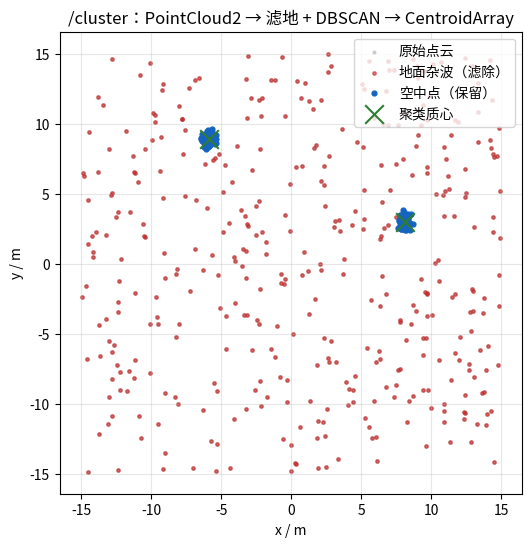

In [4]:
Z_THRESH, EPS, MIN_SAMPLES = 1.0, 0.5, 5

kept = cl.filter_ground(points, Z_THRESH)
clusters = cl.dbscan_cluster(kept, EPS, MIN_SAMPLES)
out = cn.clusters_to_centroid_array(clusters, msg.header)

print('原始点数           :', len(points))
print('滤地后点数         :', len(kept))
print('聚类数             :', len(clusters))
print('CentroidArray 条数 :', len(out.centroids))
for i, ps in enumerate(out.centroids):
    print('  簇 %d 质心 = (%.3f, %.3f, %.3f)  frame=%s'
          % (i, ps.point.x, ps.point.y, ps.point.z, ps.header.frame_id))

raw = np.array([(p.x, p.y, p.z) for p in points])
ground = raw[raw[:, 2] <= Z_THRESH]
air = raw[raw[:, 2] > Z_THRESH]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(raw[:, 0], raw[:, 1], s=4, c=C_RAW, alpha=0.4, label='原始点云')
ax.scatter(ground[:, 0], ground[:, 1], s=6, c=C_GROUND, alpha=0.6, label='地面杂波（滤除）')
ax.scatter(air[:, 0], air[:, 1], s=12, c=C_AIR, label='空中点（保留）')
ax.scatter([ps.point.x for ps in out.centroids],
           [ps.point.y for ps in out.centroids],
           s=180, marker='x', c=C_CENT, linewidths=2.5, label='聚类质心')
ax.set_xlabel('x / m')
ax.set_ylabel('y / m')
ax.set_title('/cluster：PointCloud2 → 滤地 + DBSCAN → CentroidArray')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.show()

## 3. 「空也发」：无目标时仍发布空数组

空点云 → 0 个簇 → 仍构造出一个长度为 0 的 `CentroidArray`（而非静默）。
这样全链路「空 = 没目标（业务正常）、静默 = 故障」的语义才成立，也为状态机帧计数提供节拍。

In [5]:
empty_points = cn.cloud_to_points(make_cloud([]))
empty_clusters = cl.dbscan_cluster(cl.filter_ground(empty_points, Z_THRESH), EPS, MIN_SAMPLES)
empty_out = cn.clusters_to_centroid_array(empty_clusters, None)

print('空点云 → 点数     :', len(empty_points))
print('空点云 → 簇数     :', len(empty_clusters))
print('发布数组长度      :', len(empty_out.centroids))
print('类型              :', type(empty_out).__module__ + '.' + type(empty_out).__name__)
print('「空也发」成立：目标数为 0 时仍发布空 CentroidArray，而非静默。')

空点云 → 点数     : 0
空点云 → 簇数     : 0
发布数组长度      : 0
类型              : uav_tracking.msg._CentroidArray.CentroidArray
「空也发」成立：目标数为 0 时仍发布空 CentroidArray，而非静默。
